In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import scvi
import matplotlib as mpl
import torch
import os
import os.path
from IPython.display import display

import scipy
from sklearn.neighbors import NearestNeighbors

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Set parameters

In [2]:
neighbors = 15
nPCs = 30
leiden_resolution = 1
min_distUMAP = 0.2
n_neighbors = 15

In [3]:
scvi.settings.seed = 0
batch_size = 1024
max_epochs = 1000
earlyStopping = True
learning_rate = 0.0005
scvi_layers = 4
scvi_latent = 30

torch.set_float32_matmul_precision('high')

SCVI_LATENT_KEY = "X_scvi"
SCVI_CLUSTERS_KEY = "clusters_scvi"

neighbors = 15
percentile_threshold = 80

Seed set to 0


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1614: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/Context.cpp:45.)
  _C._set_float32_matmul_precision(precision)


In [4]:
input_file = "/vast/projects/chenyuli/nephrobase/levinsj/adata/fetal_annotated_AllCells_withXenium_postSCVI1_V2.h5ad"
adata_scRNA = "/vast/projects/chenyuli/nephrobase/levinsj/adata/fetal_annotated_AllCells_model2_postSCANVI_anno.h5ad"

scVI_model_update = "/vast/projects/chenyuli/nephrobase/levinsj/scvi_models/fetal_xenium_cosmx_V3/"
output_file= "/vast/projects/chenyuli/nephrobase/levinsj/adata/fetal_annotated_AllCells_withXenium_preSCANVI_part1.h5ad"


In [5]:
adata = sc.read_h5ad(input_file)
scRNA_adata = sc.read_h5ad(adata_scRNA)
adata.obs["type"] = adata.obs["type"].replace({"fetal": "Fetal"})
print(adata)

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 947240 × 659
    obs: 'sample', 'type', 'tech', 'pct_counts_mt', 'total_counts', 'nCount_RNA', 'n_genes_by_counts', 'n_counts', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'sample_colors', 'tech_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'All_counts', 'counts', 'log1p'
    obsp: 'connectivities', 'distances'


/tmp/ipykernel_2151333/3465377410.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["type"] = adata.obs["type"].replace({"fetal": "Fetal"})


AnnData object with n_obs × n_vars = 445895 × 995
    obs: 'sample', 'phase', 'type', 'cellType', 'cellType3', 'tech', 'cellType_CosMx_1', 'leiden', 'fov', 'cell_ID', 'pct_counts_mt', 'pct_nuc', 'total_counts', 'nCount_RNA', 'n_genes_by_counts', 'CenterX_global_px', 'CenterY_global_px', 'Area', 'Count_percentile', 'Mean.DAPI', 'Max.DAPI', 'G2M_score', 'S_score', 'gAge', 'AllCounts', '_scvi_batch', '_scvi_labels', 'mean_distance', 'worst_pct', 'cellType_SCANVI', 'leiden_sub18'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cellType3_colors', 'cellType_CosMx_1_colors', 'cellType_SCANVI_colors', 'cellType_colors', 'leiden', 'leiden_sub18_colors', 'neighbors', 'sample_colors', 'tech_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scANVI', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'spatial', 'spatial_fov'
    layers: 'All_counts', 'Cytoplasm', 'Membrane', 'Nuclear', 'counts', 'log1p'
    obsp: 'connectivities', 'distances'
                     

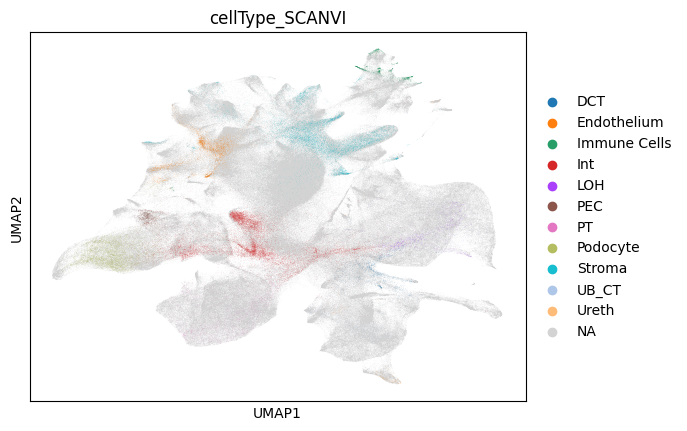

In [6]:
cellType_series = scRNA_adata.obs['cellType_SCANVI']
print(scRNA_adata)
print(scRNA_adata.obs)
reindexed_cellType = cellType_series.reindex(adata.obs_names)
adata.obs['cellType_SCANVI'] = reindexed_cellType
print(adata.obs)
sc.pl.umap(adata, color = "cellType_SCANVI")

In [7]:
print(adata)

AnnData object with n_obs × n_vars = 947240 × 659
    obs: 'sample', 'type', 'tech', 'pct_counts_mt', 'total_counts', 'nCount_RNA', 'n_genes_by_counts', 'n_counts', '_scvi_batch', '_scvi_labels', 'cellType_SCANVI'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'sample_colors', 'tech_colors', 'umap', 'cellType_SCANVI_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'All_counts', 'counts', 'log1p'
    obsp: 'connectivities', 'distances'


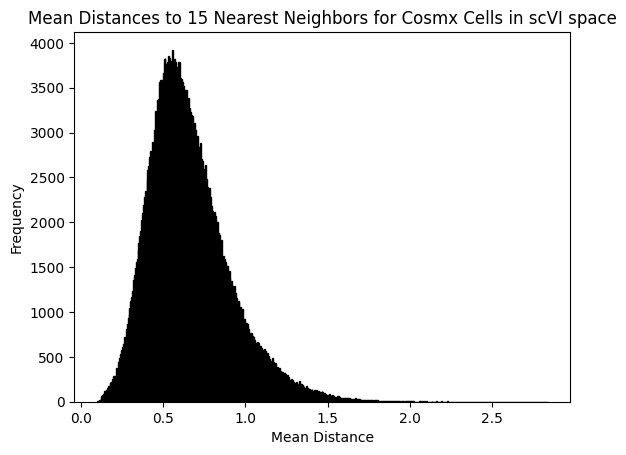

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
Cosmx_cells_mask = (adata.obs['tech'] == 'CosMx')
scRNA_cells_mask = (adata.obs['tech'] == 'scRNA')

CosMx_index = np.where(Cosmx_cells_mask)[0]
scRNA_index = np.where(scRNA_cells_mask)[0]

nn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
nn.fit(adata.obsm["X_scvi"][scRNA_cells_mask])

distances_all_to_non_Cosmx, indices_all_to_non_Cosmx = nn.kneighbors(adata.obsm["X_scvi"][Cosmx_cells_mask])

mean_distances = np.mean(distances_all_to_non_Cosmx, axis=1)
mean_distance_dict = {index: distance for index, distance in zip(adata.obs_names[Cosmx_cells_mask], mean_distances)}

adata.obs['mean_distance'] = adata.obs_names.map(mean_distance_dict)
adata.obs['mean_distance'] = adata.obs['mean_distance'].fillna(float('0'))

plt.hist(mean_distances, bins=500, edgecolor='black')
plt.title('Mean Distances to 15 Nearest Neighbors for Cosmx Cells in scVI space')
plt.xlabel('Mean Distance')
plt.ylabel('Frequency')
plt.show()

cosmx_distances = adata.obs.loc[Cosmx_cells_mask, 'mean_distance']
threshold = np.percentile(cosmx_distances, 80)
keep_mask = (adata.obs['tech'] != 'CosMx') | \
            ((adata.obs['tech'] == 'CosMx') & (adata.obs['mean_distance'] < threshold))

# 3. Apply the mask
adata = adata[keep_mask, :].copy()

In [9]:
print(adata)

AnnData object with n_obs × n_vars = 873814 × 659
    obs: 'sample', 'type', 'tech', 'pct_counts_mt', 'total_counts', 'nCount_RNA', 'n_genes_by_counts', 'n_counts', '_scvi_batch', '_scvi_labels', 'cellType_SCANVI', 'mean_distance'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'sample_colors', 'tech_colors', 'umap', 'cellType_SCANVI_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'All_counts', 'counts', 'log1p'
    obsp: 'connectivities', 'distances'


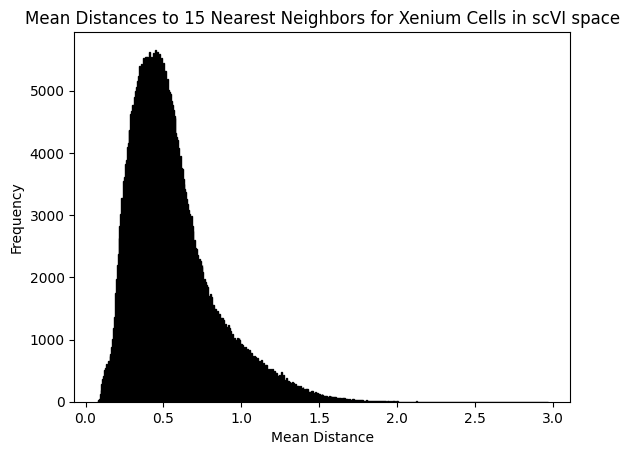

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
Xenium_cells_mask = (adata.obs['tech'] == 'Xenium')
scRNA_cells_mask = (adata.obs['tech'] == 'scRNA')

Xenium_index = np.where(Xenium_cells_mask)[0]
scRNA_index = np.where(scRNA_cells_mask)[0]

nn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
nn.fit(adata.obsm["X_scvi"][scRNA_cells_mask])

distances_all_to_non_Xenium, indices_all_to_non_Xenium = nn.kneighbors(adata.obsm["X_scvi"][Xenium_cells_mask])

mean_distances = np.mean(distances_all_to_non_Xenium, axis=1)
mean_distance_dict = {index: distance for index, distance in zip(adata.obs_names[Xenium_cells_mask], mean_distances)}

adata.obs['mean_distance'] = adata.obs_names.map(mean_distance_dict)
adata.obs['mean_distance'] = adata.obs['mean_distance'].fillna(float('0'))

plt.hist(mean_distances, bins=500, edgecolor='black')
plt.title('Mean Distances to 15 Nearest Neighbors for Xenium Cells in scVI space')
plt.xlabel('Mean Distance')
plt.ylabel('Frequency')
plt.show()

xenium_distances = adata.obs.loc[Xenium_cells_mask, 'mean_distance']
threshold = np.percentile(xenium_distances, 80)
keep_mask = (adata.obs['tech'] != 'Xenium') | \
            ((adata.obs['tech'] == 'Xenium') & (adata.obs['mean_distance'] < threshold))

# 3. Apply the mask
adata = adata[keep_mask, :].copy()

In [11]:
print(adata)

AnnData object with n_obs × n_vars = 769158 × 659
    obs: 'sample', 'type', 'tech', 'pct_counts_mt', 'total_counts', 'nCount_RNA', 'n_genes_by_counts', 'n_counts', '_scvi_batch', '_scvi_labels', 'cellType_SCANVI', 'mean_distance'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'sample_colors', 'tech_colors', 'umap', 'cellType_SCANVI_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'All_counts', 'counts', 'log1p'
    obsp: 'connectivities', 'distances'


In [12]:
scvi.model.SCVI.setup_anndata(
    adata,
    batch_key="sample",
    categorical_covariate_keys=["tech"],
    continuous_covariate_keys=["pct_counts_mt"])

model = scvi.model.SCVI(adata, n_layers=scvi_layers, n_latent=scvi_latent, gene_likelihood="nb", dropout_rate=0.1)
model.view_anndata_setup(adata)

Anndata setup with scvi-tools version 1.4.0.post1.

Setup via `SCVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': ['tech'],
│   'continuous_covariate_keys': ['pct_counts_mt']
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   10   │
│         n_cells          │ 769158 │
│ n_extra_categorical_covs │   1    │
│ n_extra_continuous_covs  │   1    │
│         n_labels         │   1    │
│          n_vars          │  659   │
└──────────────────────────┴────────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│ extra_continuous_covs  │ adata.obsm['_scvi_extra_continuous_covs']  │
│         labels         │         adata.obs['_scvi_labels']          │
└────────────────────────┴────────────────────────────────────────────┘

                   batch State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ 22020263005 │          0          │
│                     │     FK1     │          1          │
│                     │     FK4     │          2          │
│                     │   HK2716    │          3          │
│                     │   HK2718    │          4          │
│                     │   HK2722    │          5          │
│                     │   HK2723    │          6          │
│                     │   HK2725    │          7          │
│                     │   HK3524    │          8          │
│                     │   HK3888    │          9          │
└─────────────────────┴─────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

         extra_categorical_covs State Registry          
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location  ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['tech'] │   CosMx    │          0          │
│                   │   Xenium   │          1          │
│                   │   scRNA    │          2          │
│                   │            │                     │
└───────────────────┴────────────┴─────────────────────┘

 extra_continuous_covs State  
           Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['pct_counts_mt'] │
└────────────────────────────┘

In [13]:
model.train(max_epochs = max_epochs, plan_kwargs={"lr":learning_rate}, early_stopping = earlyStopping, batch_size=batch_size) 

model.save(scVI_model_update, overwrite=True)

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 777/1000:  78%|███████▊  | 776/1000 [1:14:19<21:31,  5.76s/it, v_num=1, train_loss=188]

Epoch 777/1000:  78%|███████▊  | 777/1000 [1:14:25<21:25,  5.76s/it, v_num=1, train_loss=188]

Epoch 777/1000:  78%|███████▊  | 777/1000 [1:14:25<21:25,  5.76s/it, v_num=1, train_loss=188]

Epoch 777/1000:  78%|███████▊  | 777/1000 [1:14:25<21:21,  5.75s/it, v_num=1, train_loss=188]


Monitored metric elbo_validation did not improve in the last 45 records. Best score: 187.069. Signaling Trainer to stop.


In [14]:
latent = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
latent.shape

(769158, 30)

In [15]:
adata.write(output_file)

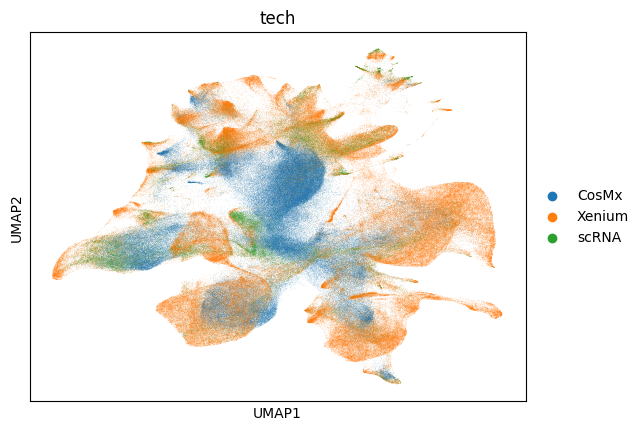

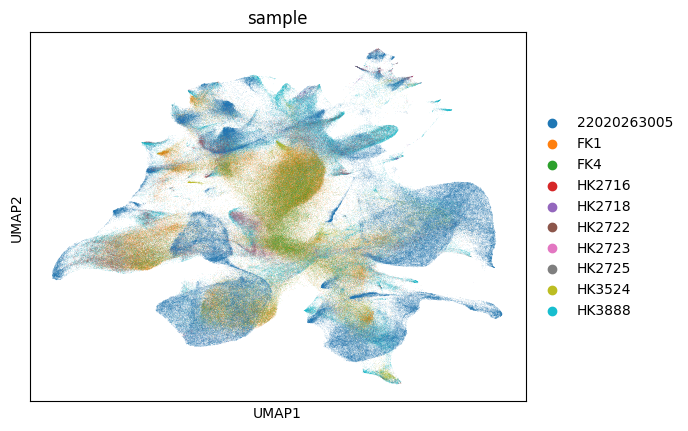

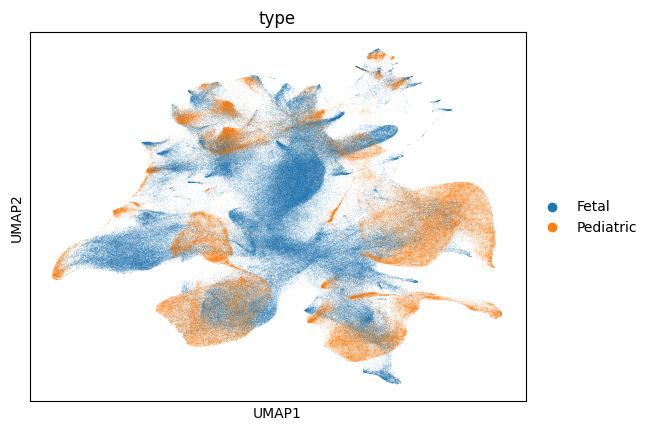

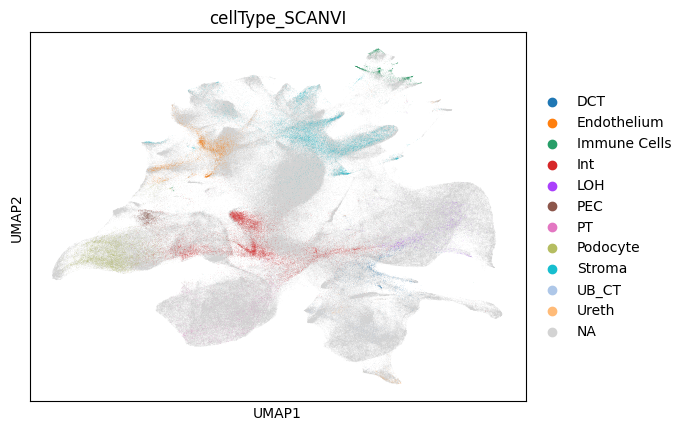

In [16]:
sc.pl.umap(adata, color = "tech")
sc.pl.umap(adata, color = "sample")
sc.pl.umap(adata, color = "type")
sc.pl.umap(adata, color = "cellType_SCANVI")